In [14]:
import pandas as pd

In [15]:
import os
os.listdir("../dataset")

['.gitkeep',
 '.ipynb_checkpoints',
 'dna_sequences.csv',
 'Ecoli CDS.txt',
 'Ecoli Promoter.csv',
 'noncoding.fasta']

In [16]:
data = pd.read_csv("../dataset/dna_sequences.csv")
data.head()

,sequence,label
0,TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGC...,Promoter
1,TGCTATCCTGACAGTTGTCACGCTGATTGGTGTCGTTACAATCTAA...,Promoter
2,GTACTAGAGAACTAGTGCATTAGCTTATTTTTTTGTTATCATGCTA...,Promoter
3,AATTGTGATGTGTATCGAAGTGTGTTGCGGAGTAGATGTTAGAATA...,Promoter
4,TCGATAATTAACTATTGACGAAAAGCTGAAAACCACTAGAATGCGC...,Promoter


In [17]:
data = data.dropna(subset=['label'])
data = data[data['label'].str.strip() != '']

data['label'].unique()
print(data['label'].value_counts())

label
Noncoding    201
Coding       129
Promoter     113
Name: count, dtype: int64


In [18]:
from sklearn.feature_extraction.text import CountVectorizer


In [19]:
k = 4 
vectorizer = CountVectorizer(analyzer='char', ngram_range=(k, k))

In [20]:
X = vectorizer.fit_transform(data['sequence'])
y = data['label']

In [21]:
print(X.shape)
print(vectorizer.get_feature_names_out()[:10])

(443, 256)
['aaaa' 'aaac' 'aaag' 'aaat' 'aaca' 'aacc' 'aacg' 'aact' 'aaga' 'aagc']


In [22]:
from sklearn.model_selection import train_test_split

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 354
Testing samples: 89


In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Try different alpha values
for a in [1.0, 0.5, 0.1, 0.01]:
    
    model = MultinomialNB(alpha=a)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print("Alpha:", a, "Accuracy:", acc)


Alpha: 1.0 Accuracy: 0.6404494382022472
Alpha: 0.5 Accuracy: 0.6404494382022472
Alpha: 0.1 Accuracy: 0.6404494382022472
Alpha: 0.01 Accuracy: 0.6404494382022472


In [24]:
from sklearn.metrics import accuracy_score, classification_report

# Predict on test data
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.6404494382022472

Classification Report:

              precision    recall  f1-score   support

      Coding       0.60      0.81      0.69        26
   Noncoding       0.69      0.45      0.55        40
    Promoter       0.64      0.78      0.71        23

    accuracy                           0.64        89
   macro avg       0.65      0.68      0.65        89
weighted avg       0.65      0.64      0.63        89



In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

import joblib

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# 👇 ADD THESE TWO LINES RIGHT HERE
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8089887640449438

Classification Report:

              precision    recall  f1-score   support

      Coding       0.91      0.77      0.83        26
   Noncoding       0.84      0.78      0.81        40
    Promoter       0.70      0.91      0.79        23

    accuracy                           0.81        89
   macro avg       0.82      0.82      0.81        89
weighted avg       0.82      0.81      0.81        89

Random Forest Accuracy: 0.8089887640449438
              precision    recall  f1-score   support

      Coding       0.91      0.77      0.83        26
   Noncoding       0.84      0.78      0.81        40
    Promoter       0.70      0.91      0.79        23

    accuracy                           0.81        89
   macro avg       0.82      0.82      0.81        89
weighted avg       0.82      0.81      0.81        89



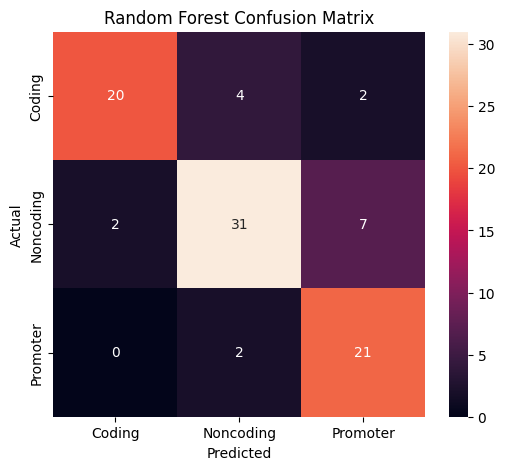

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, rf_pred)

labels = np.unique(y)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()